# Stability atlas population

How the Tier A stability atlas (#1429) distributes across the three linear-stability
questions it answers, as one 3×1 histogram figure (#1852):

1. **ideal MHD** -- DCON's least-stable $W_t$ for $n=1\ldots6$; $W_t<0$ is unstable (the sign
   only, no $|W_t|$ band);
2. **resistive** -- each slice's $\Delta'_{\max}$ over its rational surfaces, RDCON and STRIDE at
   $n=1,2$; $\Delta'_{\max}>0$, a classical tearing drive at *any* surface, is unstable;
3. **local criteria** -- Mercier $\max D_I$ (unstable $>0$) and high-$n$ ballooning $\min C_A$
   (unstable $<0$).

$W_t$ and $\Delta'$ are drawn at the higher of the atlas's two resolutions (mpsi 512) for every
slice; the local criteria exist only from the reference DCON run (mpsi 256). No QA cut is applied
to what is plotted, and a value beyond the outermost bin is drawn in the edge bin. The atlas's own
`ideal_unstable_full_edge` flag is read at mpsi 256, so its counts can differ from these where the
sign of $W_t$ flips between resolutions. How many slices pass QA, and how many sit on the
unstable side, is the reader's separate counts table below -- the raw, QA and interpretation
layers stay apart.

In [ ]:
import os
from pathlib import Path

try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt

from vaft.plot.stability_atlas import stability_atlas_population
from vaft.process.mhd_stability import load_stability_atlas, stability_atlas_populations

_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get("VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The atlas lives on vestserver at ~/runs/campaign/atlas; elsewhere point
# VAFT_ATLAS_DIR at an rsync of it.
ATLAS = Path(os.environ.get("VAFT_ATLAS_DIR", "atlas")).expanduser() / "stability"
HAVE_ATLAS = (ATLAS / "atlas_n.csv").is_file() and (ATLAS / "atlas_surfaces.csv").is_file()
print(f"stability atlas: {'found' if HAVE_ATLAS else 'not available here (set VAFT_ATLAS_DIR)'}")

stability atlas: found


## Populations and counts

`stability_atlas_populations` returns the raw values per panel and a counts table: per series
the slices drawn, the QA-passing slices (ideal: the sign of $W_t$ agrees between mpsi 256 and 512;
resistive: the maximizing surface is two-resolution consistent; local: the criterion was
evaluated) and the slices on the unstable side of the universal criterion.

In [ ]:
if HAVE_ATLAS:
    populations = stability_atlas_populations(*load_stability_atlas(ATLAS))
    print(populations.summary.to_string(index=False))
else:
    populations = None
    print("Would print, per series, the slices drawn, the QA-passing slices and the unstable ones.")

    panel     series      criterion  slices  qa  unstable
    ideal        n=1        W_t < 0     150 146         4
    ideal        n=2        W_t < 0     150 148         2
    ideal        n=3        W_t < 0     150 148         4
    ideal        n=4        W_t < 0     150 146         3
    ideal        n=5        W_t < 0     150 148         8
    ideal        n=6        W_t < 0     150 146        12
resistive  RDCON n=1 Delta'_max > 0     150  19       107
resistive  RDCON n=2 Delta'_max > 0     149  25        94
resistive STRIDE n=1 Delta'_max > 0     150  14        98
resistive STRIDE n=2 Delta'_max > 0     149  29       126
    local    max D_I        D_I > 0     150 150         1
    local    min C_A        C_A < 0     150 150        12


## The figure

Shaded halves are the two sides of each stability boundary. In the local panel the two
criteria are unstable on opposite sides of zero, so each names its own.

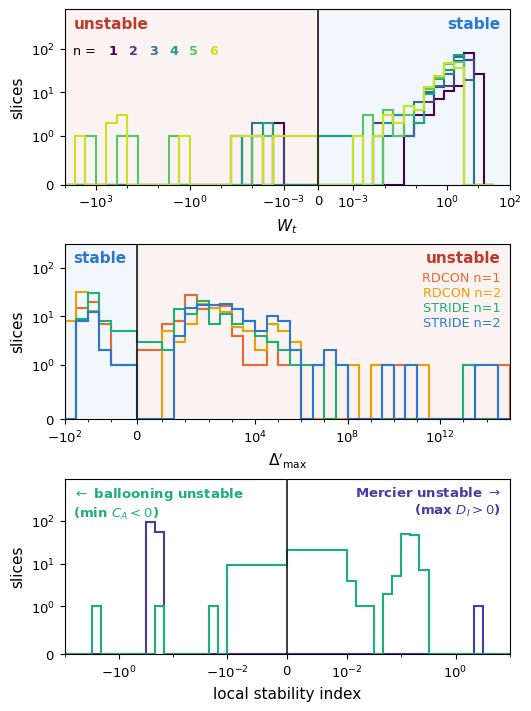

In [ ]:
if populations is not None:
    figure, axes = stability_atlas_population(populations)
    figure.savefig(OUTPUT_DIR / "stability-atlas-population.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Would draw the 3x1 population histograms of the stability atlas.")

## What this shows, and what it does not

- The ideal and resistive panels apply only the universal criteria -- the sign of $W_t$ and
  $\Delta'_{\max}>0$. Neither is a complete verdict: a positive $\Delta'$ is the classical
  outer-region drive, not a matched tearing growth rate.
- $W_t$ is DCON's normalized energy, comparable across slices by sign only.
- $\Delta'_{\max}$ hides the surface it came from; the atlas's per-surface table keeps it, and
  very large values are mostly first surfaces at low shear near $q_{\min}$ (atlas README).